In [151]:
# "C:\Users\aradhyamathv\MySQL_Connection_ML_Modelling_me.ipynb"
!pip install pymysql

In [152]:
import pymysql
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(style="white", color_codes=True)

import warnings
warnings.filterwarnings('ignore')

try:
    # Establish the connection.
    conn = pymysql.connect(
        host = '127.0.0.1',
        user = 'root',
        password = 'Sairam@12345',
        port = 3306
    )

    # Load data into DataFrame.
    query = "SELECT * FROM cars.car_price_dataset"
    df = pd.read_sql(query, conn)

    # Display the results.
    print('Connection successful. Here is your data :')
    display(df.head())

except pymysql.Error as e:
    print(f"MySQL Error : {e}")

finally:
    if 'conn' in locals():
        conn.close()
        print('Conneciton closed successfully !!!')

Connection successful. Here is your data :


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


Conneciton closed successfully !!!


In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import pickle

In [159]:
# Clean data and # Drop rows with invalid price
df = df.dropna()
df["Price"] = pd.to_numeric(df["Price"], errors='coerce')
df = df.dropna(subset=["Price"])

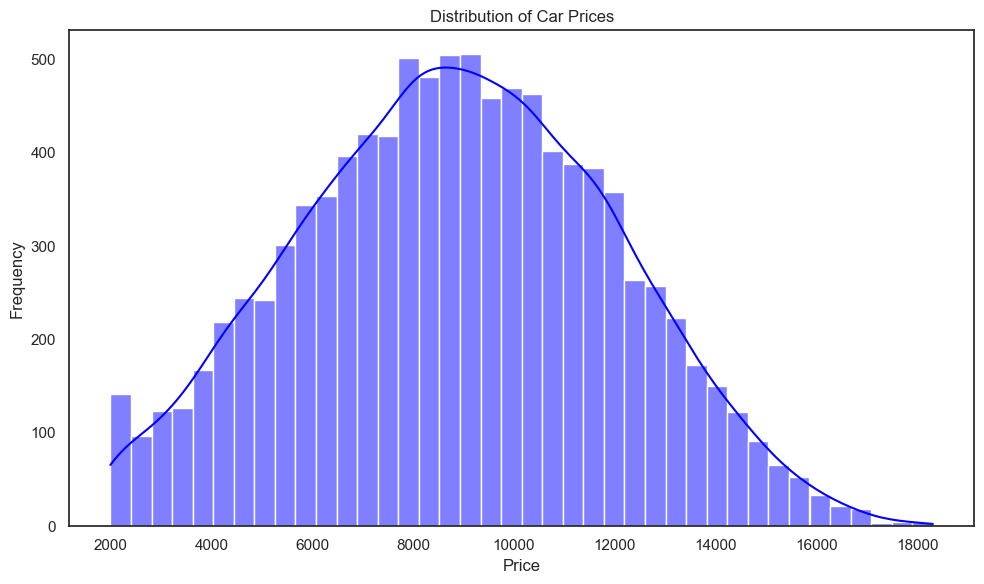

In [161]:
# EDA: Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

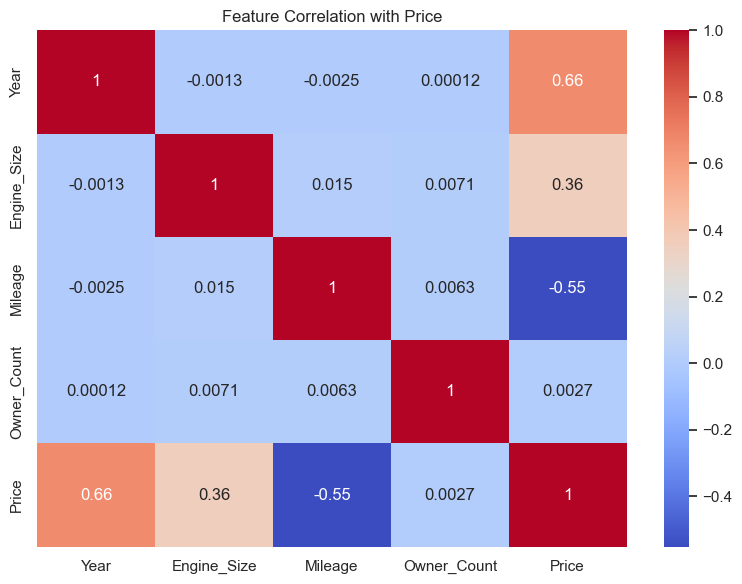

In [163]:
# EDA: Correlation Heatmap (numerical features)
numerical_cols = ["Year", "Engine_Size", "Mileage", "Owner_Count"]
corr = df[numerical_cols + ['Price']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Price")
plt.tight_layout()
plt.savefig("feature_correlation.png")
plt.show()

In [165]:
# Define features and target
X = df.drop(columns=["Price", "Model"])
y = df["Price"]

In [167]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [169]:
# Identify categorical and numerical columns
categorical_cols = ["Brand", "Fuel_Type", "Transmission", "Doors"]
numerical_cols = ["Year", "Engine_Size", "Mileage", "Owner_Count"]

In [171]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numerical_cols),
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])


In [173]:
# Full pipeline with regressor
model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

In [175]:
# Train base model
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [177]:
# Helper function for regression evaluation
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} MAE: {mae:.2f}")
    print(f"{name} MSE: {mse:.2f}")
    print(f"{name} R²: {r2:.3f}\n")

In [179]:
# Evaluate base model
print("📊 Base Model Performance:")
evaluate_model("Training", y_train, y_train_pred)
evaluate_model("Testing", y_test, y_test_pred)

📊 Base Model Performance:
Training MAE: 96.72
Training MSE: 15884.68
Training R²: 0.998

Testing MAE: 255.24
Testing MSE: 107210.44
Testing R²: 0.988



In [181]:
# Hyperparameter Tuning
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [None, 5, 10],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Year',
                                                                          'Engine_Size',
                                                                          'Mileage',
                                                                          'Owner_Count']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Brand',
                                                                          'Fuel_Type',
                                                                          'Transmission',
                                                                          'Doors'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [None, 5, 10],
                         'regressor__min_samples_leaf': [1, 2],
                         'regressor__min_samples_split': [2, 5],
                         'regressor__n_estimators': [100, 200]},
             scoring='neg_mean_absolute_error')

In [182]:
# Best model
best_model = grid_search.best_estimator_
y_train_pred_best = best_model.predict(X_train)
y_test_pred_best = best_model.predict(X_test)

In [187]:
# Evaluate best model
print("\n🏆 Best Model Performance (After Tuning):")
evaluate_model("Training", y_train, y_train_pred_best)
evaluate_model("Testing", y_test, y_test_pred_best)


🏆 Best Model Performance (After Tuning):
Training MAE: 113.77
Training MSE: 22860.45
Training R²: 0.998

Testing MAE: 249.18
Testing MSE: 103542.51
Testing R²: 0.989



In [189]:
# Save best model
with open('random_forest_classifier_car_price.pkl', 'wb') as f:
    pickle.dump(best_model, f)

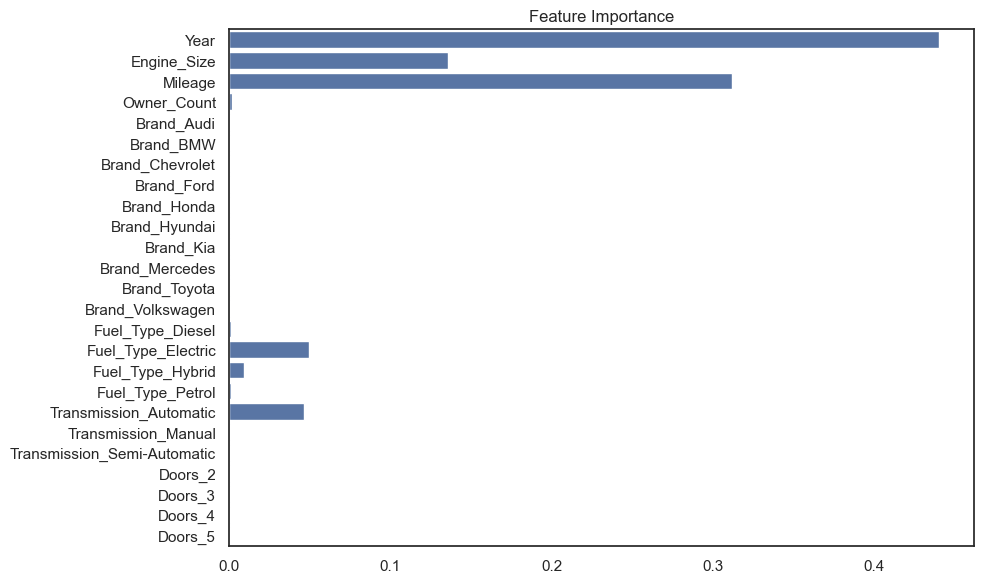

In [191]:
# Feature Importance
feature_names = numerical_cols + list(
    best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_cols)
)
importances = best_model.named_steps['regressor'].feature_importances_

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()